# Stability Analysis
This notebook reproduces the stability analysis reported in Section 5 and Table 1 of the paper:
> **Beyond Black-Box Labels: Interpretable Criteria for Diagnosing Subjective NLP Tasks**

It computes two stability measures for each criterion:
- **Activation rate** Act_t(q): proportion of corpus units where criterion q is engaged
- **Conditional vote distribution** π_q(k|t): distribution of agreement levels among engaged units

From the vote distribution, we derive three interpretable rates (for A=5 annotators):
- **NT** (near-tie): π_q(2|t) + π_q(3|t) — boundary pressure
- **AS** (asymmetric split): π_q(4|t) + π_q(1|t) — moderate agreement
- **UY** (unanimous yes): π_q(5|t) — full unanimity

**Reproduces:** Table 1 and Figure 2 of the paper.

## 1. Setup and load tensor

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

# ── Config ────────────────────────────────────────────────────────
TENSOR_DIR  = Path("../data/tensors/run_2026-04-13_14-00_FULL_AGGREGATED")
TENSOR_NPY  = TENSOR_DIR / "tensor_raw_4700.npy"

CRITERIA = [
    "q01_CostReduction",
    "q02_OperationalEfficiency", 
    "q03_OrganizationalImpact",
    "q04_UserWellbeing",
    "q05_ReputationRecognition",
    "q06_PerceivedQuality",
    "q07_RegulatoryCompliance",
    "q08_RiskPrevention",
    "q09_MandatoryRequirement",
]

MODELS = [
    "gemini-2.0-flash-001",
    "gpt-4.1-mini",
    "gpt-4.1",
    "llama-3.3-70b",
    "mistral-large-2411",
    "qwen-2.5-72b",
]

A = 5        # number of annotators in main panel (excluding Gemini)
t = 1        # engagement threshold
N_CRITERIA = 9


# ── Load tensor ───────────────────────────────────────────────────
tensor = np.load(TENSOR_NPY)

# Use only main panel (A=5, excluding Gemini-2.0-flash-001 at index 0)
# Gemini is used only for LOO robustness check (Appendix J)
tensor_main = tensor[:, :N_CRITERIA, 1:]  # shape: (4700, 9, 5)

# Drop sentences with any missing value (-1)
valid_mask = np.all(tensor_main != -1, axis=(1,2))
tensor_main = tensor_main[valid_mask]
N_SENTENCES = tensor_main.shape[0]

print(f"Tensor shape (full)  : {tensor.shape}")
print(f"Tensor shape (main)  : {tensor_main.shape}")
print(f"Valid sentences      : {N_SENTENCES}")
print(f"Panel size           : {A} models")
print(f"Engagement threshold : t={t}")


Tensor shape (full)  : (4700, 11, 6)
Tensor shape (main)  : (4698, 9, 5)
Valid sentences      : 4698
Panel size           : 5 models
Engagement threshold : t=1


## 2. Compute focus sets and activation rates

In [13]:
# ── Vote counts v_sq ──────────────────────────────────────────────
# For each (sentence, criterion), sum votes across A models
# tensor_main: (N_sentences, N_criteria, A)
# Replace -1 (missing) with 0 for vote counting
tensor_votes = np.where(tensor_main == -1, 0, tensor_main)
vote_counts = tensor_votes.sum(axis=2)  # shape: (4699, 9)

# ── Focus sets Ω_q,t ─────────────────────────────────────────────
# For each criterion q, focus set = sentences where v_sq >= t
focus_sets = vote_counts >= t  # shape: (4699, 9), boolean

# ── Activation rates Act_t(q) ─────────────────────────────────────
activation_rates = focus_sets.sum(axis=0) / N_SENTENCES  # shape: (9,)

print("Activation rates Act_t(q) at t=1:")
for i, crit in enumerate(CRITERIA):
    print(f"  {crit}: {activation_rates[i]*100:.1f}%  ({focus_sets[:,i].sum()} units)")

Activation rates Act_t(q) at t=1:
  q01_CostReduction: 2.8%  (131 units)
  q02_OperationalEfficiency: 9.4%  (443 units)
  q03_OrganizationalImpact: 12.6%  (592 units)
  q04_UserWellbeing: 9.7%  (458 units)
  q05_ReputationRecognition: 17.6%  (826 units)
  q06_PerceivedQuality: 24.1%  (1130 units)
  q07_RegulatoryCompliance: 5.8%  (273 units)
  q08_RiskPrevention: 14.1%  (662 units)
  q09_MandatoryRequirement: 10.3%  (482 units)


## 3. Compute conditional vote distribution π_q(k|t)

In [14]:
# ── π_q(k|t) for k in {t, ..., A} ────────────────────────────────
# For each criterion q and vote count k, compute proportion of 
# focus set units receiving exactly k positive votes

pi = np.zeros((N_CRITERIA, A+1))  # pi[q, k] = π_q(k|t)

for q in range(N_CRITERIA):
    focus_idx = focus_sets[:, q]  # boolean mask
    focus_votes = vote_counts[focus_idx, q]  # vote counts in focus set
    n_focus = focus_idx.sum()
    
    if n_focus > 0:
        for k in range(t, A+1):
            pi[q, k] = (focus_votes == k).sum() / n_focus

print("Vote distribution π_q(k|t) computed for all criteria.")

Vote distribution π_q(k|t) computed for all criteria.


## 4. Derive stability metrics (NT, AS, UY)

In [15]:
# For A=5:
# NT (near-tie)        = π_q(2|t) + π_q(3|t)
# AS (asymmetric split)= π_q(4|t) + π_q(1|t)  
# UY (unanimous yes)   = π_q(5|t)

NT = pi[:, 2] + pi[:, 3]
AS = pi[:, 4] + pi[:, 1]
UY = pi[:, 5]

# ── Build Table 1 ─────────────────────────────────────────────────
table1 = pd.DataFrame({
    "Criterion"   : CRITERIA,
    "Act1 (%)"    : (activation_rates * 100).round(1),
    "NT%"         : (NT * 100).round(1),
    "AS%"         : (AS * 100).round(1),
    "UY%"         : (UY * 100).round(1),
    "|Ω_q,1|"     : focus_sets.sum(axis=0).astype(int),
})

print("\nTable 1: Criterion stability at t=1")
print(table1.to_string(index=False))


Table 1: Criterion stability at t=1
                Criterion  Act1 (%)  NT%  AS%  UY%  |Ω_q,1|
        q01_CostReduction       2.8 22.9 45.8 31.3      131
q02_OperationalEfficiency       9.4 28.2 43.3 28.4      443
 q03_OrganizationalImpact      12.6 28.9 44.8 26.4      592
        q04_UserWellbeing       9.7 35.8 48.3 15.9      458
q05_ReputationRecognition      17.6 34.0 52.3 13.7      826
     q06_PerceivedQuality      24.1 23.3 31.9 44.9     1130
 q07_RegulatoryCompliance       5.8 25.6 44.7 29.7      273
       q08_RiskPrevention      14.1 27.8 36.9 35.3      662
 q09_MandatoryRequirement      10.3 38.2 41.7 20.1      482


## 5. Figure 2: Stability landscape

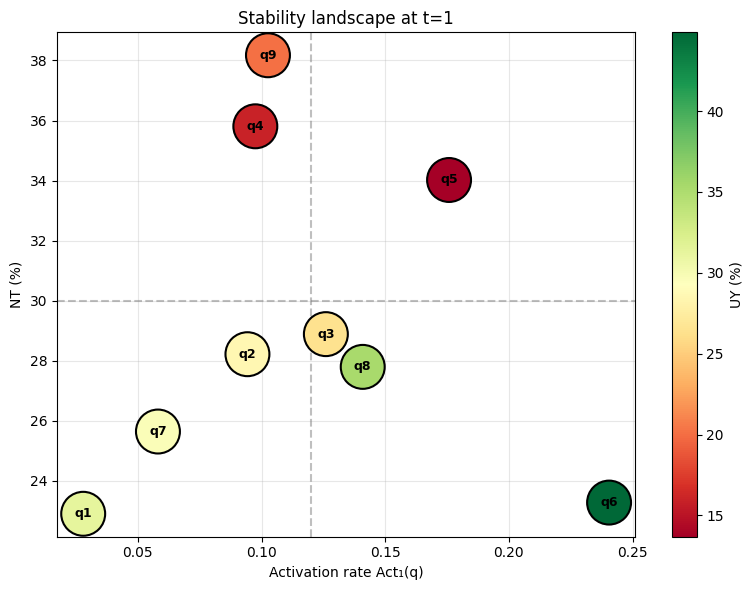

In [21]:
fig, ax = plt.subplots(figsize=(8, 6))

scatter = ax.scatter(
    activation_rates,
    NT * 100,
    c=UY * 100,
    cmap="RdYlGn",
    s=1000,                    # bigger circles
    zorder=3,
    edgecolors='black',       # black border
    linewidths=1.5
)

# Quadrant lines
ax.axvline(x=0.12, color='gray', linestyle='--', alpha=0.5)
ax.axhline(y=30, color='gray', linestyle='--', alpha=0.5)



# Criterion labels INSIDE circles
short_names = ["q1","q2","q3","q4","q5","q6","q7","q8","q9"]
for i, name in enumerate(short_names):
    ax.annotate(name,
                (activation_rates[i], NT[i]*100),
                ha='center',
                va='center',
                fontsize=9,
                fontweight='bold',
                zorder=4)

plt.colorbar(scatter, ax=ax, label="UY (%)")
ax.set_xlabel("Activation rate Act₁(q)")
ax.set_ylabel("NT (%)")
ax.set_title("Stability landscape at t=1")
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig("../results/figure2_stability_landscape.png", dpi=150, bbox_inches="tight")
plt.show()